# Comparative Autoregressive (Rolling) Error Analysis: GINO vs FNO
This notebook analyzes and compares the error accumulation over time for Initial-Value Problem (IVP) rolling predictions between GINO and FNO models.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
import os

# Set a nice plotting style
plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 6)})


## 1. Load Data


In [147]:
# GINO_RESULTS_DIR = Path('/scratch/yl75/ak4177/results/groundwater/GINO_predictions/var_loss/resolution_1.0/gino_predictions_20260817_161903/rolling_sequence')
GINO_RESULTS_DIR = Path('/scratch/yl75/ak4177/results/groundwater/GINO_predictions/standard/resolution_1.0/gino_predictions_20260818_093327/rolling_sequence')
FNO_RESULTS_DIR = Path('/scratch/yl75/ak4177/results/groundwater/FNO_predictions/forcing/resolution_1.0/fno_predictions_20260818_085739/rolling_sequence')
FNO_V2_RESULTS_DIR = Path('/scratch/yl75/ak4177/results/groundwater/FNO_predictions/forcing_v2/resolution_1.0/fno_predictions_20260819_145350/rolling_sequence')

# Load metadata
with open(GINO_RESULTS_DIR / 'metadata.json', 'r') as f:
    metadata = json.load(f)
    
target_cols = metadata.get('args', {}).get('target_cols', ['mass_concentration', 'head'])
print(f"Target columns: {target_cols}")

print("Loading arrays (this may take a moment)...")
gino_preds = np.load(GINO_RESULTS_DIR / 'val_predictions.npy')
fno_preds = np.load(FNO_RESULTS_DIR / 'val_predictions.npy')
fno_v2_preds = np.load(FNO_V2_RESULTS_DIR / 'val_predictions.npy')
targets = np.load(GINO_RESULTS_DIR / 'val_targets.npy')

print(f"GINO Predictions shape: {gino_preds.shape}")
print(f"FNO Predictions shape: {fno_preds.shape}")
print(f"FNO V2 Predictions shape: {fno_v2_preds.shape}")
print(f"Targets shape: {targets.shape}")


Target columns: ['mass_concentration', 'head']
Loading arrays (this may take a moment)...
GINO Predictions shape: (568, 61360, 1, 2)
FNO Predictions shape: (568, 61360, 1, 2)
FNO V2 Predictions shape: (28, 61360, 20, 2)
Targets shape: (568, 61360, 1, 2)


In [148]:
fno_v2_preds = np.expand_dims(np.concatenate(np.transpose(fno_v2_preds, (0, 2, 1, 3)), 0), 2)
# fno_v2_preds = np.expand_dims(fno_v2_preds[:, :, 0, :], 2)
fno_v2_preds.shape

(560, 61360, 1, 2)

In [149]:


# gino_preds = gino_preds[5:-19]
# fno_preds = fno_preds[5:-19]
# targets = targets[5:-19]

gino_preds = gino_preds[5:-3]
fno_preds = fno_preds[5:-3]
targets = targets[5:-3]

print(f"GINO Predictions shape: {gino_preds.shape}")
print(f"FNO Predictions shape: {fno_preds.shape}")
print(f"FNO Predictions shape: {fno_v2_preds.shape}")
print(f"Targets shape: {targets.shape}")

GINO Predictions shape: (560, 61360, 1, 2)
FNO Predictions shape: (560, 61360, 1, 2)
FNO Predictions shape: (560, 61360, 1, 2)
Targets shape: (560, 61360, 1, 2)


In [150]:
n_steps, n_points, w_out, n_cols = gino_preds.shape
gino_preds.shape

(560, 61360, 1, 2)

In [151]:
gino_preds.shape

(560, 61360, 1, 2)

14107


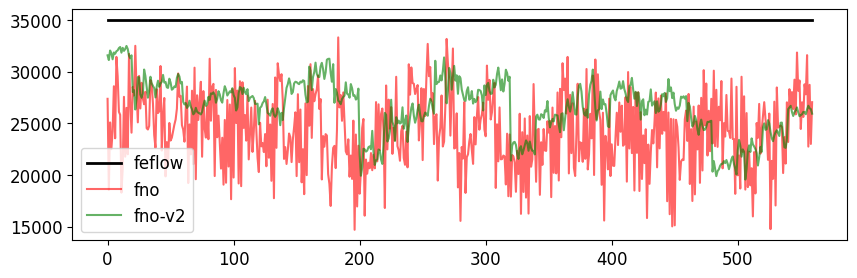

In [158]:
randidx = np.random.randint(gino_preds.shape[1]) # 17702
colidx = 0

print(randidx)

fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(targets[:, randidx, 0, colidx], label='feflow', color='black', linewidth=2)
ax.plot(fno_preds[:, randidx, 0, colidx], label='fno', color='red', alpha=0.6)
ax.plot(fno_v2_preds[:, randidx, 0, colidx], label='fno-v2', color='green', alpha=0.6)

plt.legend()


## 2. Compute Spatially Averaged Error over Time


In [153]:
def calculate_errors_vs_time(preds, targets, n_steps, n_cols):
    rel_l2 = np.zeros((n_cols, n_steps))
    rmse = np.zeros((n_cols, n_steps))
    
    for c in range(n_cols):
        for t in range(n_steps):
            p_t = preds[t, :, 0, c]
            t_t = targets[t, :, 0, c]
            
            diff = p_t - t_t
            rmse[c, t] = np.sqrt(np.mean(diff**2))
            
            target_norm = np.linalg.norm(t_t)
            if target_norm > 1e-8:
                rel_l2[c, t] = np.linalg.norm(diff) / target_norm
            else:
                rel_l2[c, t] = np.linalg.norm(diff)
                
    return rel_l2, rmse

gino_rel_l2, gino_rmse = calculate_errors_vs_time(gino_preds, targets, n_steps, n_cols)
fno_rel_l2, fno_rmse = calculate_errors_vs_time(fno_preds, targets, n_steps, n_cols)
fno_v2_rel_l2, fno_v2_rmse = calculate_errors_vs_time(fno_v2_preds, targets, n_steps, n_cols)


## 3. Valid Prediction Horizon (VPH)


In [154]:
def compute_vph(rel_l2, threshold=0.20):
    vph = {}
    for c, col in enumerate(target_cols):
        errors = rel_l2[c]
        exceed_idx = np.where(errors > threshold)[0]
        if len(exceed_idx) > 0:
            vph[col] = exceed_idx[0]
        else:
            vph[col] = len(errors)
    return vph

gino_vph_10 = compute_vph(gino_rel_l2, threshold=0.10)
gino_vph_20 = compute_vph(gino_rel_l2, threshold=0.20)
fno_vph_10 = compute_vph(fno_rel_l2, threshold=0.10)
fno_vph_20 = compute_vph(fno_rel_l2, threshold=0.20)
fno_v2_vph_10 = compute_vph(fno_v2_rel_l2, threshold=0.10)
fno_v2_vph_20 = compute_vph(fno_v2_rel_l2, threshold=0.20)

print("--- Valid Prediction Horizon (VPH) ---")
for col in target_cols:
    print(f"\n{col}:")
    print(f"  GINO VPH @ 10% error = {gino_vph_10[col]} steps | FNO VPH @ 10% error = {fno_v2_vph_10[col]} steps")
    print(f"  GINO VPH @ 20% error = {gino_vph_20[col]} steps | FNO VPH @ 20% error = {fno_v2_vph_20[col]} steps")


--- Valid Prediction Horizon (VPH) ---

mass_concentration:
  GINO VPH @ 10% error = 0 steps | FNO VPH @ 10% error = 0 steps
  GINO VPH @ 20% error = 5 steps | FNO VPH @ 20% error = 0 steps

head:
  GINO VPH @ 10% error = 0 steps | FNO VPH @ 10% error = 0 steps
  GINO VPH @ 20% error = 0 steps | FNO VPH @ 20% error = 0 steps


## 4. Plot Comparative Error Accumulation


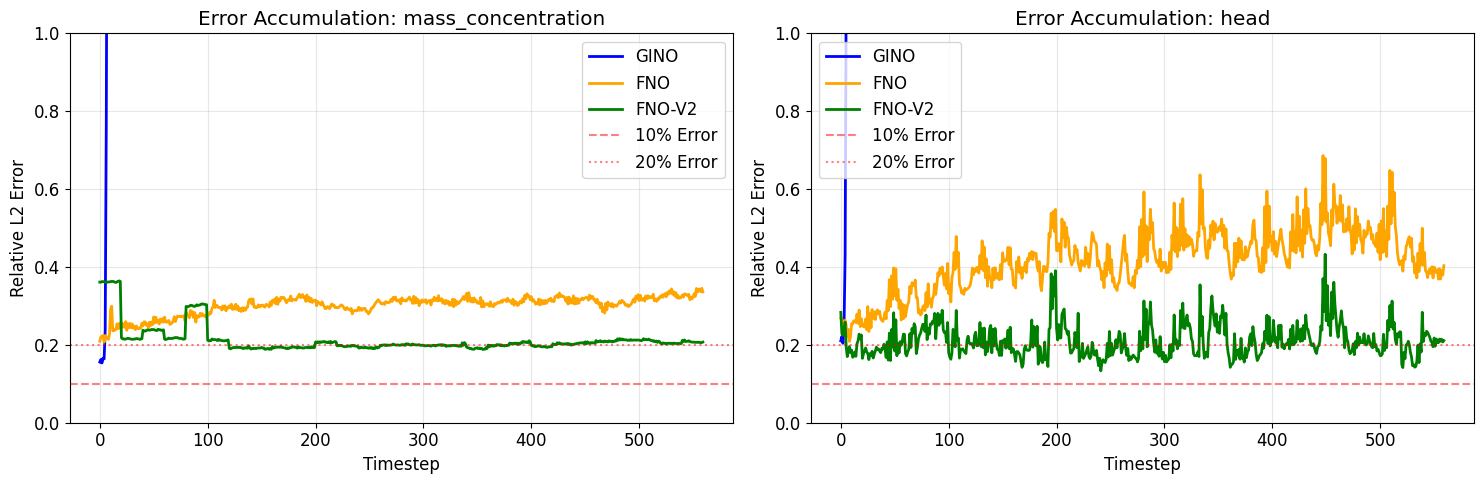

In [155]:
fig, axes = plt.subplots(1, n_cols, figsize=(15, 5))
if n_cols == 1:
    axes = [axes]

for c, col in enumerate(target_cols):
    ax = axes[c]
    ax.plot(gino_rel_l2[c], label='GINO', color='blue', linewidth=2)
    ax.plot(fno_rel_l2[c], label='FNO', color='orange', linewidth=2)
    ax.plot(fno_v2_rel_l2[c], label='FNO-V2', color='green', linewidth=2)
    
    ax.axhline(y=0.10, color='r', linestyle='--', alpha=0.5, label='10% Error')
    ax.axhline(y=0.20, color='r', linestyle=':', alpha=0.5, label='20% Error')
    
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Relative L2 Error')
    ax.set_title(f'Error Accumulation: {col}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()


In [ ]:
# fig, axes = plt.subplots(1, n_cols, figsize=(15, 5))
# if n_cols == 1:
#     axes = [axes]

# for c, col in enumerate(target_cols):
#     ax = axes[c]
#     ax.plot(gino_rmse[c], label='GINO', color='blue', linewidth=2)
#     ax.plot(fno_rmse[c], label='FNO', color='orange', linewidth=2)
    
#     ax.axhline(y=0.10, color='r', linestyle='--', alpha=0.5, label='10% Error')
#     ax.axhline(y=0.20, color='r', linestyle=':', alpha=0.5, label='20% Error')
    
#     ax.set_xlabel('Timestep')
#     ax.set_ylabel('Relative L2 Error')
#     ax.set_title(f'Error Accumulation: {col}')
#     ax.legend()
#     ax.grid(True, alpha=0.3)
#     ax.set_ylim(0, 2.0e)
#     ax.set_xlim(0, 20)
    

# plt.tight_layout()
# plt.show()